In [6]:
import pandas as pd

df = pd.read_csv("student_score_prediction_dataset.csv")

df.head()

,Study_Hours,Attendance,Previous_Score,Final_Score
0,4.4,63.3,54.4,52.30
1,9.6,79.4,53.6,69.88
2,7.6,94.3,89.8,80.54
3,6.4,88.0,53.7,54.53
4,2.4,91.3,55.0,54.12


In [7]:
df.isnull().sum()

,0
Study_Hours,0
Attendance,0
Previous_Score,0
Final_Score,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Study_Hours     1000 non-null   float64
 1   Attendance      1000 non-null   float64
 2   Previous_Score  1000 non-null   float64
 3   Final_Score     1000 non-null   float64
dtypes: float64(4)
memory usage: 31.4 KB


In [10]:
df.describe()

,Study_Hours,Attendance,Previous_Score,Final_Score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.413500,77.816300,67.631100,59.374740
std,2.630701,13.147811,15.988064,11.063692
min,1.000000,55.100000,40.000000,28.040000
25%,3.100000,65.875000,54.375000,51.382500
50%,5.500000,78.350000,67.500000,59.300000
75%,7.700000,89.200000,81.725000,67.270000
max,10.000000,100.000000,94.900000,88.500000


In [11]:
df.corr()

,Study_Hours,Attendance,Previous_Score,Final_Score
Study_Hours,1.000000,0.029592,0.014334,0.716177
Attendance,0.029592,1.000000,0.027398,0.320793
Previous_Score,0.014334,0.027398,1.000000,0.533630
Final_Score,0.716177,0.320793,0.533630,1.000000


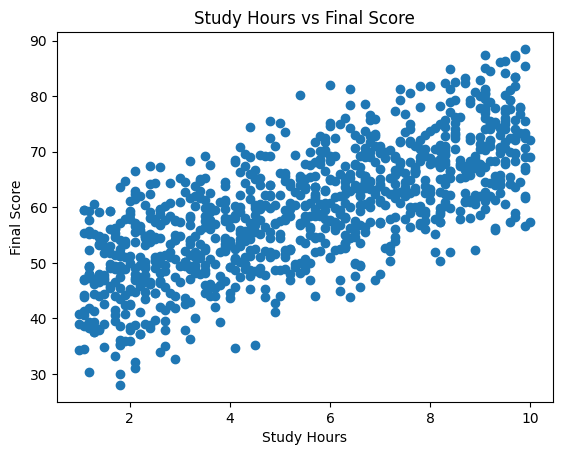

In [12]:
import matplotlib.pyplot as plt

plt.scatter(df["Study_Hours"], df["Final_Score"])
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")
plt.show()

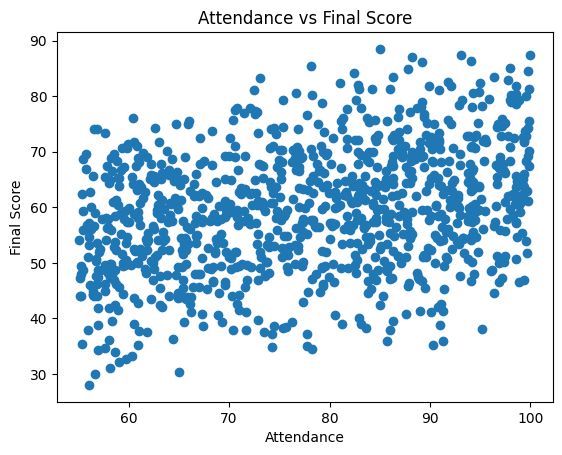

In [13]:
plt.scatter(df["Attendance"], df["Final_Score"])
plt.xlabel("Attendance")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")
plt.show()

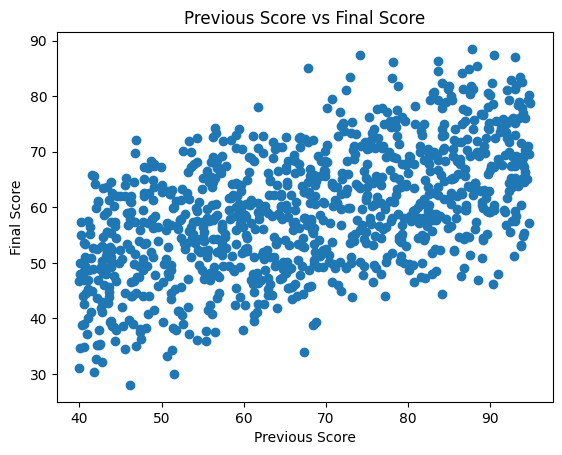

In [14]:
plt.scatter(df["Previous_Score"], df["Final_Score"])
plt.xlabel("Previous Score")
plt.ylabel("Final Score")
plt.title("Previous Score vs Final Score")
plt.show()

Observation: Previous Score shows a positive relationship with Final Score. Students with higher previous scores generally tend to have higher final scores.


### EDA Findings

Study Hours has the strongest relationship with Final Score.
Previous Score also shows a positive relationship with Final Score.
Attendance has a weaker positive relationship with Final Score.
Overall, Study Hours appears to be the most influential feature among these three.


In [15]:
X = df[["Study_Hours", "Attendance", "Previous_Score"]]
y = df["Final_Score"]

X.head()

,Study_Hours,Attendance,Previous_Score
0,4.4,63.3,54.4
1,9.6,79.4,53.6
2,7.6,94.3,89.8
3,6.4,88.0,53.7
4,2.4,91.3,55.0


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 3)
Testing data: (200, 3)


In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

y_pred[:5]

array([53.6658458 , 65.5728813 , 59.40520274, 56.21437083, 60.74941683])

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 3.51167207210449
MSE: 17.76129810776717
R² Score: 0.8709347045182007


In [20]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_pred[:5]

array([50.02, 60.83, 58.44, 52.97, 56.21])

In [21]:
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree MAE:", tree_mae)
print("Decision Tree MSE:", tree_mse)
print("Decision Tree R²:", tree_r2)

Decision Tree MAE: 5.0483
Decision Tree MSE: 40.304763
Decision Tree R²: 0.7071190340730762


### Model Comparison

Linear Regression performed better than Decision Tree Regressor on the test dataset. It achieved a lower MAE of 3.51 and MSE of 17.76, with an R² score of 0.871. The Decision Tree achieved an MAE of 5.05, MSE of 40.30, and R² score of 0.707. Therefore, Linear Regression was selected as the better-performing model for this dataset
